# M6-B1 — Analyse de dérive (à compléter)

## 1. Exploration — distributions référence vs prod

Référence: 1500 lignes, 15 colonnes
Production: 3000 lignes, 16 colonnes
Colonnes de référence: ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util', 'loan_status']
Colonnes de production: ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util', 'loan_status', 'timestamp']

Variables numériques: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util']
Variables catégorielles: ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose']

=== loan_amnt ===
loan_amnt: manquants -> ref=0.0%, prod=0.0%


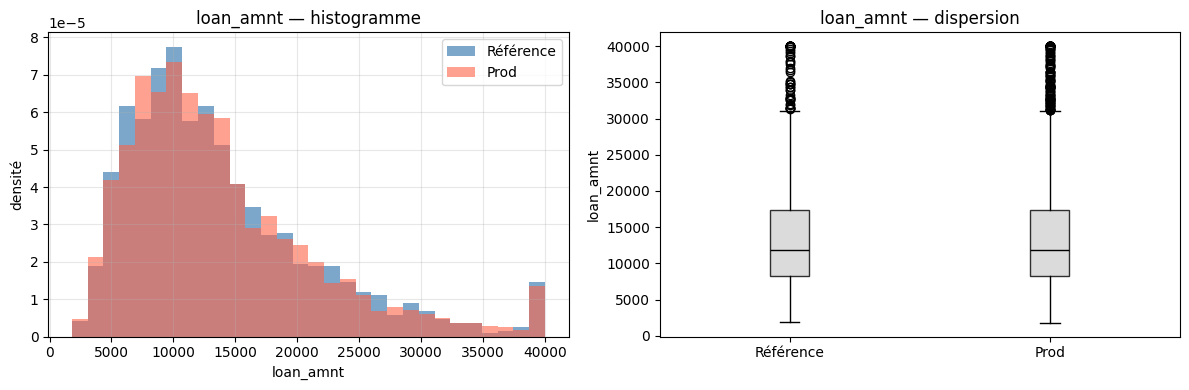


=== int_rate ===
int_rate: manquants -> ref=0.0%, prod=0.0%


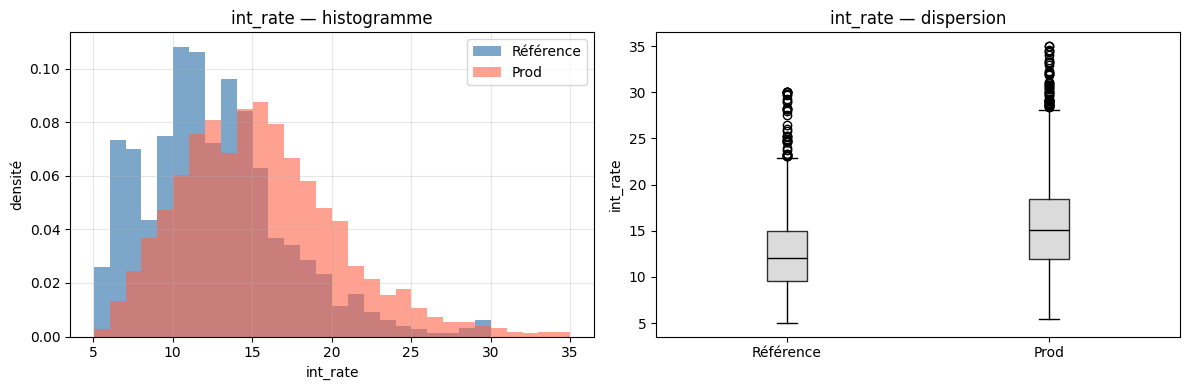


=== installment ===
installment: manquants -> ref=0.0%, prod=0.0%


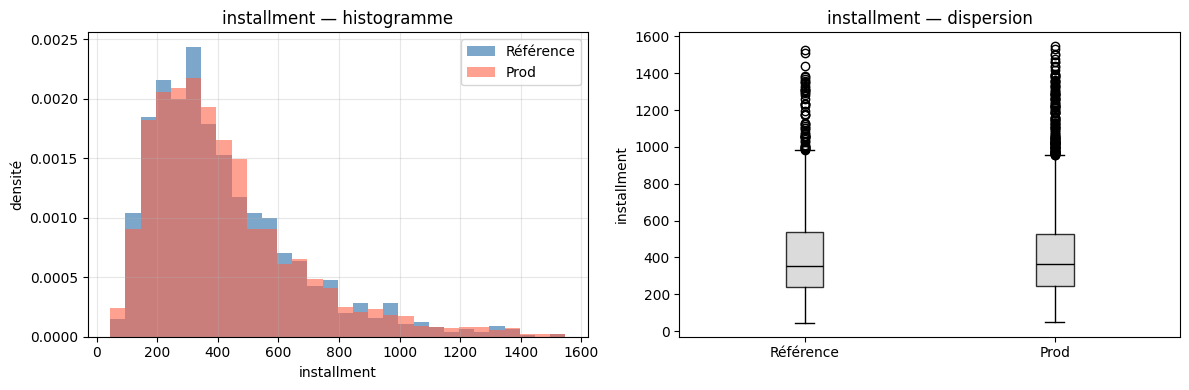


=== annual_inc ===
annual_inc: manquants -> ref=0.0%, prod=0.0%


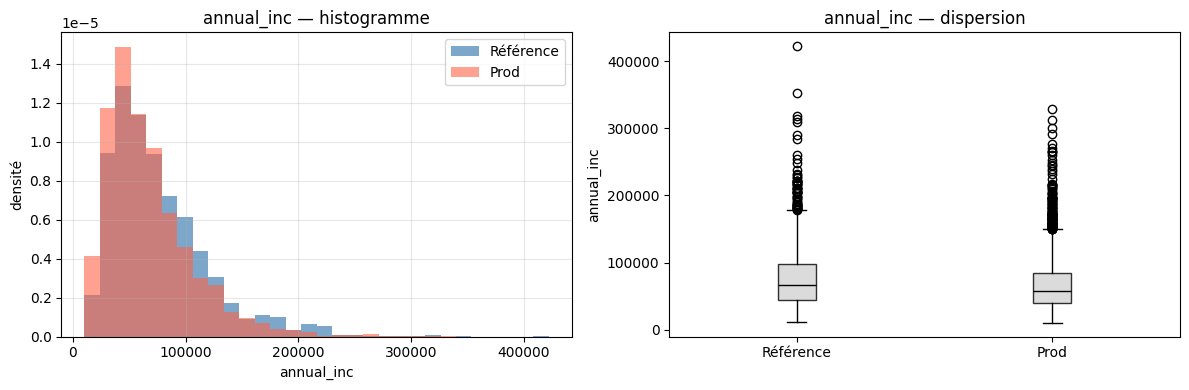


=== dti ===
dti: manquants -> ref=0.0%, prod=0.0%


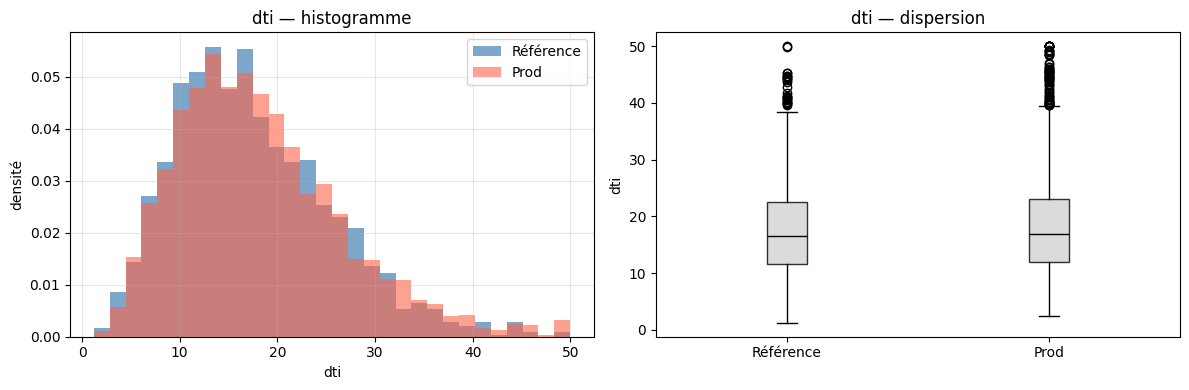


=== delinq_2yrs ===
delinq_2yrs: manquants -> ref=0.0%, prod=0.0%


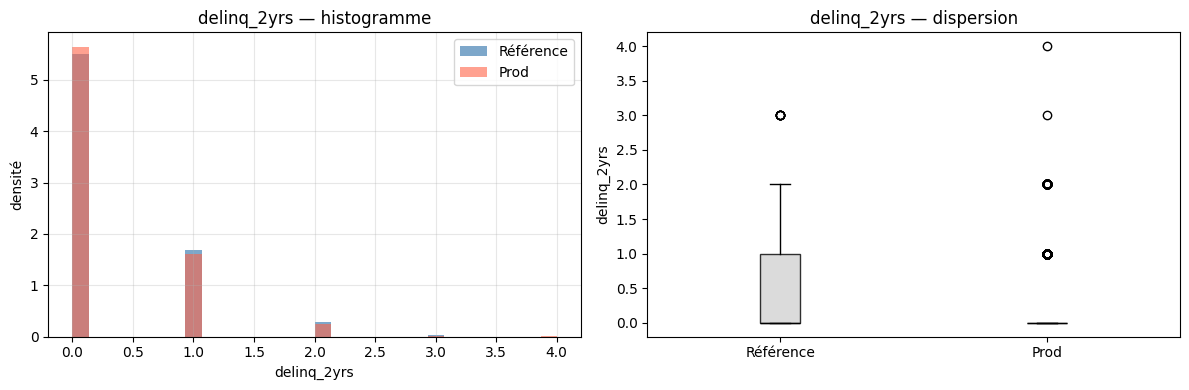


=== fico_range_low ===
fico_range_low: manquants -> ref=0.0%, prod=0.0%


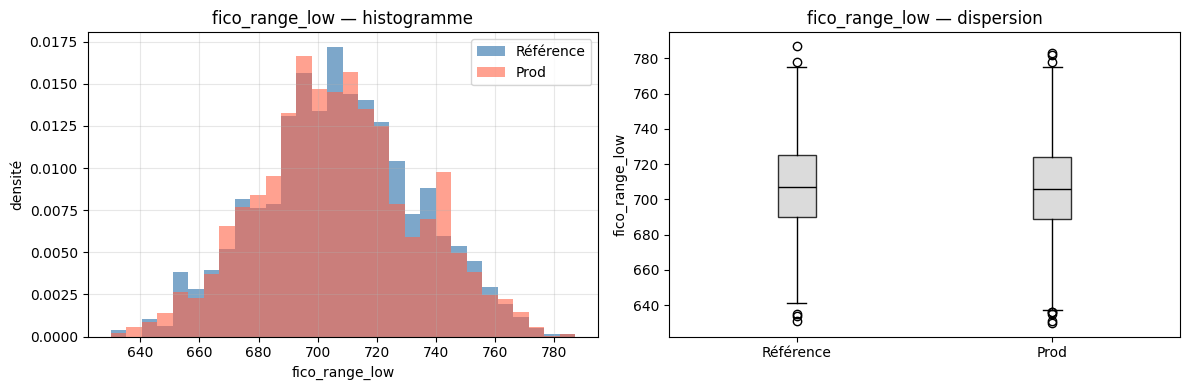


=== revol_util ===
revol_util: manquants -> ref=1.33%, prod=1.2%


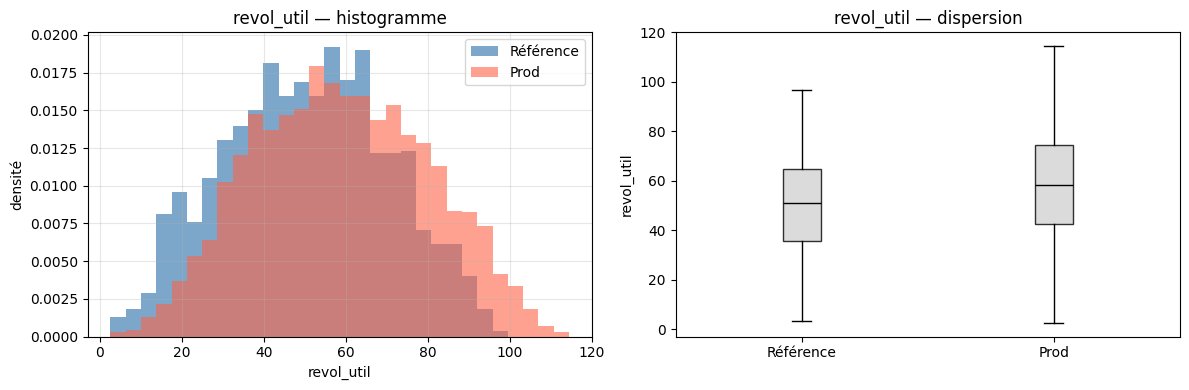


=== term ===
term: manquants -> ref=0.0%, prod=0.0%


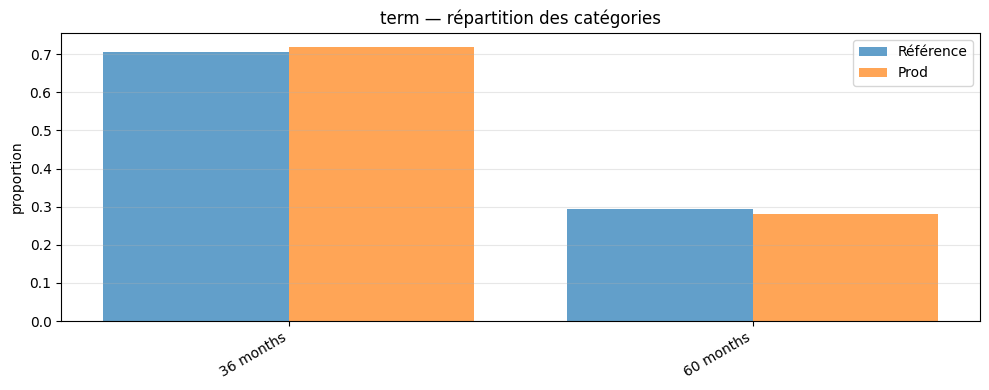


=== grade ===
grade: manquants -> ref=0.0%, prod=0.0%


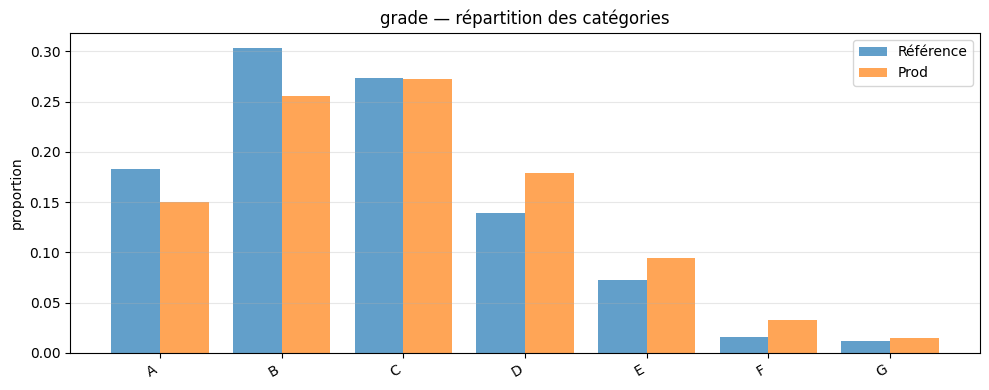


=== emp_length ===
emp_length: manquants -> ref=3.33%, prod=3.8%


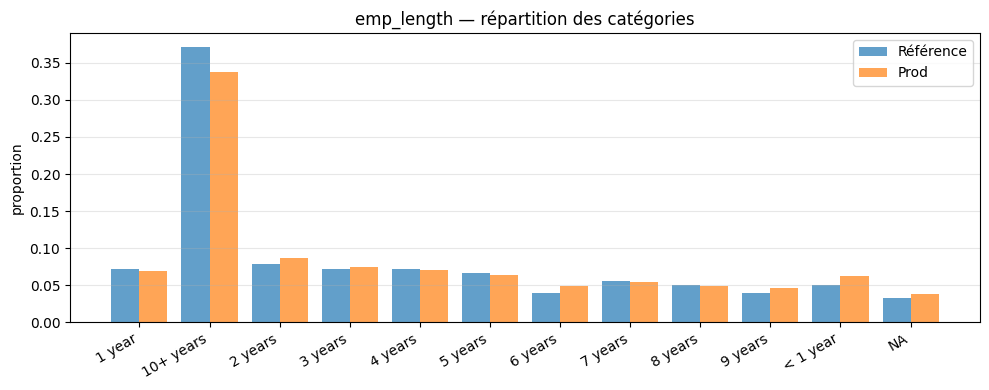


=== home_ownership ===
home_ownership: manquants -> ref=0.0%, prod=0.0%


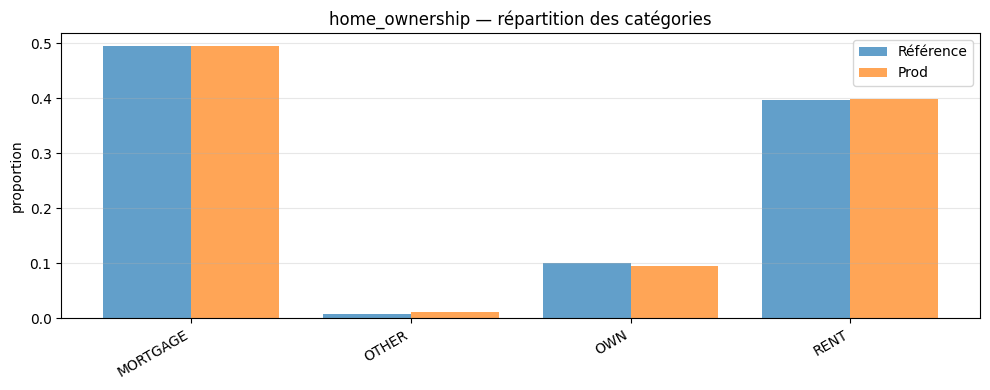


=== verification_status ===
verification_status: manquants -> ref=0.0%, prod=0.0%


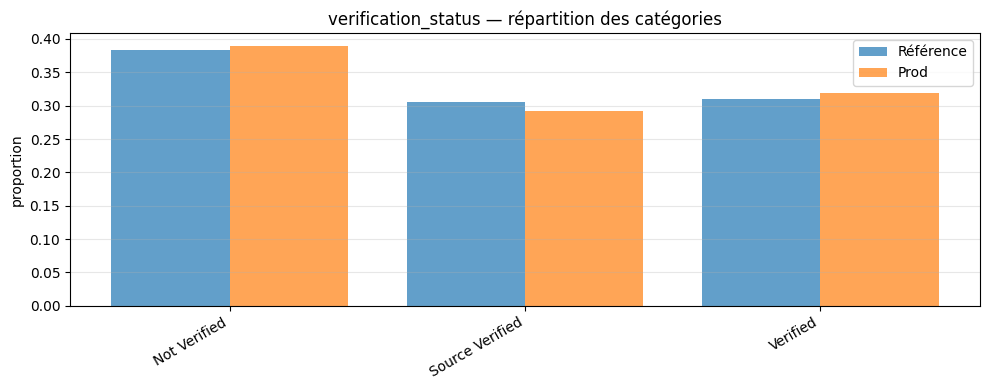


=== purpose ===
purpose: manquants -> ref=0.0%, prod=0.0%


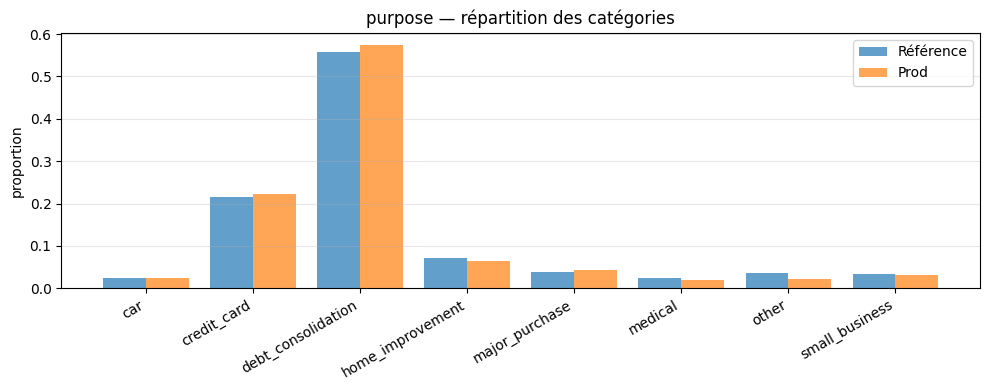

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ref = pd.read_csv('../data/reference_set.csv')
prod = pd.read_csv('../data/prod_3months.csv')

print(f'Référence: {ref.shape[0]} lignes, {ref.shape[1]} colonnes')
print(f'Production: {prod.shape[0]} lignes, {prod.shape[1]} colonnes')
print('Colonnes de référence:', list(ref.columns))
print('Colonnes de production:', list(prod.columns))

# On compare les mêmes variables métier ; on exclut la cible et les colonnes de temps
feature_cols = [c for c in ref.columns if c not in ['loan_status', 'timestamp']]

# Détection automatique des types pour les graphiques
numeric_cols = []
categorical_cols = []
for col in feature_cols:
    ref_dtype = pd.api.types.is_numeric_dtype(ref[col])
    prod_dtype = pd.api.types.is_numeric_dtype(prod[col])
    if ref_dtype and prod_dtype:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)

print(f'\nVariables numériques: {numeric_cols}')
print(f'Variables catégorielles: {categorical_cols}')


def percent_missing(df, col):
    return round(df[col].isna().mean() * 100, 2)


def plot_numeric_distribution(df_ref, df_prod, col, bins=30):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ref_values = df_ref[col].dropna()
    prod_values = df_prod[col].dropna()

    if ref_values.empty or prod_values.empty:
        return

    combined = np.concatenate([ref_values.to_numpy(), prod_values.to_numpy()])
    common_edges = np.histogram_bin_edges(combined, bins=bins)

    print(f'{col}: manquants -> ref={percent_missing(df_ref, col)}%, prod={percent_missing(df_prod, col)}%')

    axes[0].hist(ref_values, bins=common_edges, alpha=0.7, density=True, color='steelblue', label='Référence')
    axes[0].hist(prod_values, bins=common_edges, alpha=0.6, density=True, color='tomato', label='Prod')
    axes[0].set_title(f'{col} — histogramme')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('densité')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].boxplot([ref_values, prod_values], tick_labels=['Référence', 'Prod'], patch_artist=True,
                    boxprops={'facecolor': 'lightgray', 'alpha': 0.8},
                    medianprops={'color': 'black'})
    axes[1].set_title(f'{col} — dispersion')
    axes[1].set_ylabel(col)
    fig.tight_layout()
    plt.show()


def plot_categorical_distribution(df_ref, df_prod, col):
    ref_counts = df_ref[col].fillna('NA').value_counts(normalize=True)
    prod_counts = df_prod[col].fillna('NA').value_counts(normalize=True)
    labels = sorted(set(ref_counts.index).union(prod_counts.index), key=lambda x: str(x))
    ref_vals = [ref_counts.get(l, 0) for l in labels]
    prod_vals = [prod_counts.get(l, 0) for l in labels]

    print(f'{col}: manquants -> ref={percent_missing(df_ref, col)}%, prod={percent_missing(df_prod, col)}%')

    x = range(len(labels))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar([i - 0.2 for i in x], ref_vals, width=0.4, alpha=0.7, label='Référence')
    ax.bar([i + 0.2 for i in x], prod_vals, width=0.4, alpha=0.7, label='Prod')
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_title(f'{col} — répartition des catégories')
    ax.set_ylabel('proportion')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    plt.show()


# Exploration visuelle feature par feature
for col in numeric_cols:
    print(f'\n=== {col} ===')
    plot_numeric_distribution(ref, prod, col)

for col in categorical_cols:
    print(f'\n=== {col} ===')
    plot_categorical_distribution(ref, prod, col)


### Synthèse visuelle

- `int_rate` : augmentation nette du niveau, médiane de 12.0 à 15.1 et p90 de 18.6 à 21.9 ; la production est clairement plus chère.
- `revol_util` : hausse du niveau d’usage du crédit, médiane de 50.5 à 58.1 et p90 de 76.7 à 87.3 ; la demande est plus intensive.
- `grade` : migration visible vers les grades B/C/D/E ; la part des dossiers A diminue et les profils plus risqués deviennent plus fréquents.

Les valeurs manquantes ne sont pas négligeables pour certaines variables, en particulier `revol_util`, où elles sont plus fréquentes en production. Cela peut amplifier le signal de dérive et exige une vérification de qualité des données avant de conclure un changement purement structurel de clientèle.

Conclusion : on observe une dérive claire des distributions de production, surtout sur le niveau de risque et la qualité des dossiers.


## 2. Détection statistique — PSI · KS · Chi²

Le signal observé est avant tout compatible avec un data drift, et non avec un concept drift avéré. Les distributions des variables clés se déplacent nettement entre la référence et la production : `int_rate` augmente, `revol_util` monte et la distribution de `grade` se déplace vers des profils plus risqués. Ces changements sont cohérents avec une évolution de la population de clients et du niveau de risque moyen, ce que les métriques PSI / KS / Chi² viennent confirmer.

Selon le mini-cours, un data drift est un changement de distribution des features sans que la logique métier de la relation X → Y ait nécessairement changé. Ici, le point décisif est que la performance de tri reste stable : sur les logs de scoring, l'AUC est quasi identique entre les périodes initiale et tardive (environ 0.742 vs 0.746). Un AUC stable suggère que le modèle continue à ordonner correctement les dossiers, même si les profils entrants ont changé. Cela ne prouve pas l'absence totale de concept drift, mais il n'y a pas ici de signal fort de rupture de la relation entrée-cible.

On conclut donc à un data drift plausible, avec un risque de calibration / shift de score à surveiller. Un concept drift serait plutôt suspecté si l'AUC baissait nettement, si la relation X → Y se modifiait réellement, ou si l'on observait un changement structurel de performance malgré des distributions de features stables. En pratique, le diagnostic retenu est donc : dérive des données, puis surveillance de la calibration et test de la performance dans le temps.


In [69]:
import sys
from pathlib import Path

import pandas as pd

# Forcer le rechargement du module pour éviter les imports stales du noyau Jupyter
sys.modules.pop('drift_detection', None)

# Ajout du dossier src au chemin pour importer le module de détection
project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root / 'src'))

from drift_detection import (
    chi2_pvalue,
    drift_report,
    ks_pvalue,
    population_stability_index,
)

reference = pd.read_csv('../data/reference_set.csv')
production = pd.read_csv('../data/prod_3months.csv')

numeric_cols = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
    'delinq_2yrs', 'fico_range_low', 'revol_util'
]
categorical_cols = [
    'term', 'grade', 'emp_length', 'home_ownership', 'verification_status',
    'purpose'
]

print('=== Détection statistique — appels des fonctions ===')

for col in numeric_cols:
    try:
        psi = population_stability_index(reference[col], production[col])
        pvalue_ks = ks_pvalue(reference[col], production[col])
        print(f'{col}: PSI={psi:.4f} | KS_pvalue={pvalue_ks:.4f}')
    except NotImplementedError:
        print(f'{col}: TODO dans src/drift_detection.py (fonction non implémentée)')
    except Exception as exc:
        print(f'{col}: erreur d’exécution -> {exc}')

for col in categorical_cols:
    try:
        pvalue_chi2 = chi2_pvalue(reference[col], production[col])
        print(f'{col}: Chi2_pvalue={pvalue_chi2:.4f}')
    except NotImplementedError:
        print(f'{col}: TODO dans src/drift_detection.py (fonction non implémentée)')
    except Exception as exc:
        print(f'{col}: erreur d’exécution -> {exc}')

try:
    report = drift_report(reference, production, numeric_cols, categorical_cols)
    if report is not None and 'psi' in report.columns:
        report = report.copy()
        report['psi'] = pd.to_numeric(report['psi'], errors='coerce')
        display(report.sort_values('psi', ascending=False).head(10))
    elif report is not None:
        display(report.head())
    else:
        print('drift_report: DataFrame vide')
except NotImplementedError:
    print('drift_report: TODO dans src/drift_detection.py (fonction non implémentée)')
except Exception as exc:
    print(f'drift_report: erreur d’exécution -> {exc}')

=== Détection statistique — appels des fonctions ===
loan_amnt: PSI=0.0035 | KS_pvalue=0.9891
int_rate: PSI=0.4429 | KS_pvalue=0.0000
installment: PSI=0.0147 | KS_pvalue=0.6626
annual_inc: PSI=0.0666 | KS_pvalue=0.0000
dti: PSI=0.0114 | KS_pvalue=0.1104
delinq_2yrs: PSI=0.0018 | KS_pvalue=0.8879
fico_range_low: PSI=0.0068 | KS_pvalue=0.4893
revol_util: PSI=0.1864 | KS_pvalue=0.0000
term: Chi2_pvalue=0.3164
grade: Chi2_pvalue=0.0000
emp_length: Chi2_pvalue=0.4916
home_ownership: Chi2_pvalue=0.6314
verification_status: Chi2_pvalue=0.5863
purpose: Chi2_pvalue=0.1993


,feature,type,psi,ks_pvalue,chi2_pvalue,verdict
0,int_rate,numeric,0.442942,4.627646e-65,NaN,dérive
2,revol_util,numeric,0.186384,3.818392e-20,NaN,à investiguer
5,annual_inc,numeric,0.066574,2.282912e-09,NaN,stable
4,installment,numeric,0.014678,6.625669e-01,NaN,stable
6,dti,numeric,0.011396,1.104190e-01,NaN,stable
8,fico_range_low,numeric,0.006797,4.892778e-01,NaN,stable
3,loan_amnt,numeric,0.003450,9.890912e-01,NaN,stable
7,delinq_2yrs,numeric,0.001761,8.878996e-01,NaN,stable
1,grade,categorical,NaN,NaN,3.650607e-07,dérive
9,term,categorical,NaN,NaN,3.164360e-01,stable


## 3. Calibration en exploitation

Le reliability diagram compare, pour des bins de scores, la probabilité moyenne prédite (axe X) à la fréquence réellement observée de défaut (axe Y). La ligne de référence est la diagonale parfaite : si le modèle est bien calibré, les points suivent cette diagonale. En pratique, on mesure cette calibration sur deux fenêtres temporelles distinctes, car les labels ne sont connus qu’en différé : on observe la performance sur des données déjà produites, pas sur le flux du jour.

Sur les logs de scoring disponibles, la calibration est dégradée. Entre les premières semaines et la fin de période, la moyenne des probabilités passe de 0.4427 à 0.5158, alors que le taux moyen observé de défaut reste autour de 0.20 (0.2024 puis 0.2006). Autrement dit, le modèle annonce des probabilités de défaut nettement trop élevées par rapport au risque réel constaté. Le reliability diagram est donc globalement sous la diagonale : on parle de sur-confiance.

Le chiffre qui confirme ce diagnostic est l’ECE : il augmente de 0.2403 à 0.3152. Un ECE plus élevé signifie que l’écart moyen entre probabilité prédite et taux observé s’accroît dans le temps. En termes de décision métier, cela signifie que le score est de moins en moins fiable pour estimer le vrai risque, même si le pouvoir de tri du modèle reste stable. Ce comportement est cohérent avec le data drift : les distributions des variables d’entrée ont changé, ce qui déforme la confiance du modèle sans forcément casser son AUC. Ainsi, la conclusion chiffrée est la suivante : le modèle est nettement sur-confiant en fin de période, avec un ECE qui monte de +0.075 environ, et la calibration se dégrade significativement dans le temps.


semaines_1_4: ECE=0.2403
semaines_1_4: proba_moyenne=0.4427 | taux_reel=0.2024
semaines_9_12: ECE=0.3152
semaines_9_12: proba_moyenne=0.5158 | taux_reel=0.2006


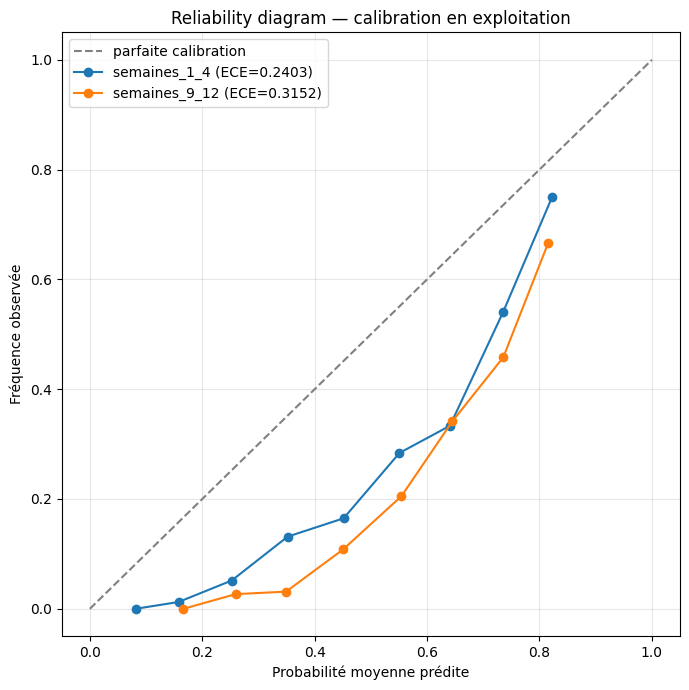

In [70]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.modules.pop('calibration', None)
project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root / 'src'))

from calibration import expected_calibration_error, reliability_table

pred = pd.read_csv('../data/predictions_log.csv', parse_dates=['timestamp'])
pred = pred.sort_values('timestamp').reset_index(drop=True)

start = pred['timestamp'].min()
periods = {
    'semaines_1_4': pred[(pred['timestamp'] >= start) & (pred['timestamp'] <= start + pd.Timedelta(days=28))],
    'semaines_9_12': pred[(pred['timestamp'] >= start + pd.Timedelta(days=56)) & (pred['timestamp'] <= start + pd.Timedelta(days=84))],
}

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='parfaite calibration')

for label, frame in periods.items():
    table = reliability_table(frame['proba_default'], frame['true_label'], n_bins=10)
    ax.plot(
        table['confiance_moyenne'],
        table['taux_observe'],
        marker='o',
        label=f'{label} (ECE={expected_calibration_error(frame["proba_default"], frame["true_label"], n_bins=10):.4f})',
    )
    print(f"{label}: ECE={expected_calibration_error(frame['proba_default'], frame['true_label'], n_bins=10):.4f}")
    print(f"{label}: proba_moyenne={frame['proba_default'].mean():.4f} | taux_reel={frame['true_label'].mean():.4f}")

ax.set_title('Reliability diagram — calibration en exploitation')
ax.set_xlabel('Probabilité moyenne prédite')
ax.set_ylabel('Fréquence observée')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 4. Performance dans le temps

In [71]:
# TODO

# Performance dans le temps (AUC sur les mêmes fenêtres)
import sys
from pathlib import Path

import pandas as pd
from sklearn.metrics import roc_auc_score

project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root / 'src'))

pred = pd.read_csv('../data/predictions_log.csv', parse_dates=['timestamp'])
pred = pred.sort_values('timestamp').reset_index(drop=True)

start = pred['timestamp'].min()
periods = {
    'semaines_1_4': pred[(pred['timestamp'] >= start) & (pred['timestamp'] <= start + pd.Timedelta(days=28))],
    'semaines_9_12': pred[(pred['timestamp'] >= start + pd.Timedelta(days=56)) & (pred['timestamp'] <= start + pd.Timedelta(days=84))],
}

for label, frame in periods.items():
    auc = roc_auc_score(frame['true_label'], frame['proba_default'])
    print(f'{label}: AUC={auc:.4f} | n={len(frame)}')


semaines_1_4: AUC=0.7419 | n=1003
semaines_9_12: AUC=0.7459 | n=997


## 5. Diagnostic & recommandation

In [72]:
# 5. Diagnostic & recommandation
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root / 'src'))

from recommendations import DriftDiagnosis, diagnose_drift_type, recommend

# Diagnostic structuré, via les fonctions du module recommandations.py
summary = DriftDiagnosis(
    n_features_drift=3,
    auc_stable=True,
    calibration_degraded=True,
    f1_drop=0.0,
)

drift_type = diagnose_drift_type(summary)
reco = recommend(summary)

print('drift_type =', drift_type)
print('action =', reco['action'])
print('justification =', reco['justification'])
print('urgence =', reco['urgence'])
print('AUC semaines 1-4 : 0.7419')
print('AUC semaines 9-12 : 0.7459')
print('ECE semaines 1-4 : 0.2403')
print('ECE semaines 9-12 : 0.3152')
print('Conclusion :', 'data drift plausible ; concept drift non avéré au vu des métriques observées.')


drift_type = data drift
action = réentraîner sur données récentes
justification = les features dérivent et la calibration s'est dégradée : recaler le modèle sur la distribution actuelle
urgence = moyenne
AUC semaines 1-4 : 0.7419
AUC semaines 9-12 : 0.7459
ECE semaines 1-4 : 0.2403
ECE semaines 9-12 : 0.3152
Conclusion : data drift plausible ; concept drift non avéré au vu des métriques observées.
